In [53]:
import sys
import os

# Add parent directory to path to import from src/
# Get the notebook's directory, then go up one level to project root
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Adam

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(44)
np.random.seed(44)

Project root: d:\Research\smap recharge\SMAP-Recharge-Flux
Using device: cpu


In [54]:
# Import normalization helper from external module
from src.normalization_helper import NormalizationHelper


In [55]:
# Import PINN models from external module
from src.pinn_models import PressureHeadNet, WaterTableNet, RichardsPINN


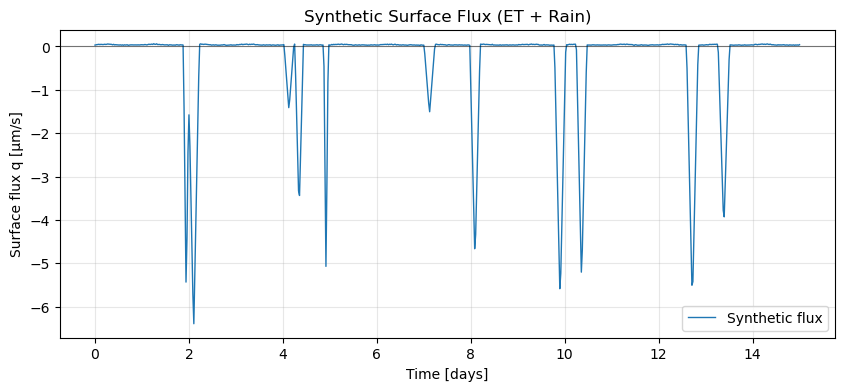

Flux range: -6.39 to 0.06 μm/s
Duration: 15.0 days, 721 points


In [56]:
from src.surf_flux import synth_surface_flux
t, q = synth_surface_flux(total_days=15, dt_minutes=30, storm_rate_per_day=0.7, min_storm_hours=2,  seed=16)
q_actual_flux = (t.tolist(), q.tolist())
# Plot the synthetic surface flux
plt.figure(figsize=(10,4))
plt.plot(t/86400, q*1e6, '-', lw=1, label='Synthetic flux')
plt.axhline(0, color='k', lw=0.8, alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Surface flux q [μm/s]")
plt.title("Synthetic Surface Flux (ET + Rain)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Flux range: {q.min()*1e6:.2f} to {q.max()*1e6:.2f} μm/s")
print(f"Duration: {t[-1]/86400:.1f} days, {len(t)} points")

In [57]:
from scipy.io import loadmat
import numpy as np

mat = loadmat("../data/q0_timeseries.mat")
q0_data = -mat["q0_data"]
q0_data[0] = 0
T_sub = np.arange(len(q0_data)) * 1800  # 1800 seconds = 30 minutes

q_cczo_flux = (T_sub.tolist(), q0_data.tolist())

Detected 69 initial spike points
Merged into 9 spike events
Total indices in merged events: 166


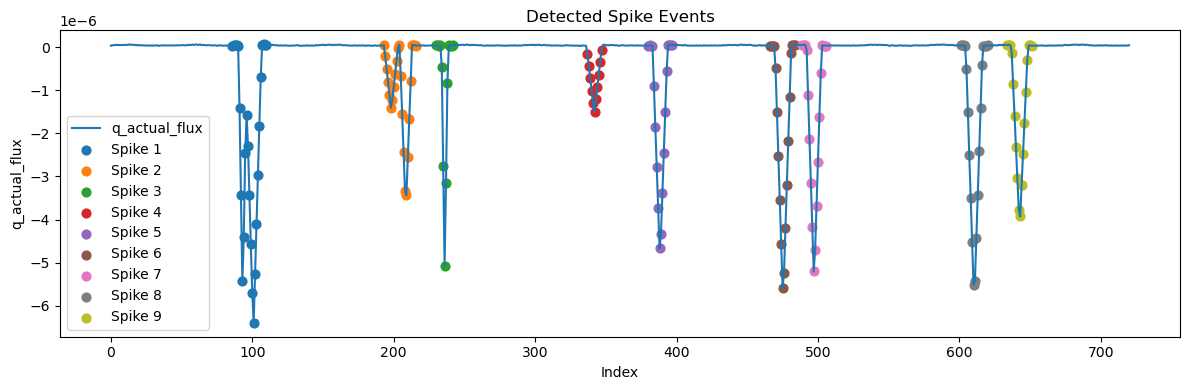

In [58]:
# Import spike detection function from external module
from src.spike_detection import detect_spike_events

q= torch.tensor(q_actual_flux[1]);

spike_events, total_spike_indices = detect_spike_events(
    q,
    threshold_method='std',      # or 'percentile' or 'iqr'
    threshold_value=1.0,         # 3 standard deviations
    expansion_window=5,          # expand ±5 points around spike
    merge_distance=3,            # merge events if gap ≤ 3 points
    min_event_size=2,            # keep events with at least 2 points
    device=device                # add device parameter
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(q.cpu().numpy(), label='q_actual_flux')
for i, event_indices in enumerate(spike_events):
    plt.scatter(event_indices.cpu().numpy(), q[event_indices].cpu().numpy(), label=f'Spike {i+1}', s=40)
plt.xlabel('Index')
plt.ylabel('q_actual_flux')
plt.title('Detected Spike Events')
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
# Import boundary sampling function from external module
from src.boundary_sampling import sample_boundary_points

In [60]:
# Import sampling helpers and loss computation functions from external module
from src.training_utils import (
    SamplingHelpers, 
    compute_losses, 
    apply_weights_and_compute_gradients, 
    apply_weights_fixed_mode
)
# Import WeightManager from external module
from src.training_utils import WeightManager
# Import CachePoolManager from external module
from src.training_utils import CachePoolManager
# Import gradient computation utilities from external module
from src.training_utils import compute_grad_norm, compute_total_grad_norm
# Import TrainingLogger from external module
from src.training_logger import TrainingLogger
#training function
from src.train_loop import train_pinn_pool_batch_autoweight


In [61]:
soil_params = {
    'theta_s': 0.4,
    'theta_r': 0.1,
    'alpha': 0.005,
    'n': 1.3,
    'Ks': 1e-5,
    'l': 0.5
}

# Define network configurations
h_net_config = {'hidden_dim': 64, 'num_layers': 4}
zb_net_config = {'hidden_dim': 32, 'num_layers': 3}

# Test the normalized PINN training
print("Testing Normalized Pool + Batch Training with Boundary Focus")
print("="*60)

# Train with pool + batch approach
model_pool, losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs = train_pinn_pool_batch_autoweight(
    soil_params=soil_params,
    q0_data=q_actual_flux,
    Sy=0.3,
    zr=0.5,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,
    L=4.0,  # ← ADD: Characteristic length scale (domain depth)
    S_max=1e-7,  # ← ADD: Maximum sink term
    n_epochs=200000,
    learning_rate=8e-4,
    zb_initial=1,
    weight_update_freq=1e10,
    weight_lr=0.1,
    use_initial_scales=True,  
    # Pool + batch parameters
    cache_size=10000,
    batch_size=500,
    resample_freq=500,
    boundary_ratio=0.7,
    high_residual_ratio=0.3,
    temperature=1.0,
    n_events=9,
    batch_size_bc=200,
    device=device,  # ← Add device parameter
    spike_events=spike_events,  # ← Add spike_events parameter
    checkpoint_dir='checkpoints_train',
    checkpoint_freq=5000,
)

Testing Normalized Pool + Batch Training with Boundary Focus

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.300
Time scale (T):             1.20e+05 s (33.33 hours)
Dimensionless α̃:            0.0200
Dimensionless S̃_max:        0.0400

Fixed weights mode enabled (weight_update_freq=10000000000.0 >= n_epochs=200000)
Checkpointing enabled: saving every 5000 epochs to checkpoints_train/
Training for 200000 epochs | lr=0.0008
Device: cpu | GPUs available: 0
Adaptive weighting: updating every 10000000000.0 epochs
Pool + Batch: cache_size=10000, batch_size=500, resample_freq=500
Boundary ratio: 70.0%, High residual ratio: 30.0%
Time domain from q0: t∈[0.000, 1296000.000], z adaptive in [-z_b(t), 0]
Initial weights: {'pde': 10.0, 'surf': 50.0, 'wt_head': 1.0, 'wt_kin': 1.0, 'ic_h': 1.0, 'ic_zb': 1.0}

[   1/200000]
  Losses: total=3.8

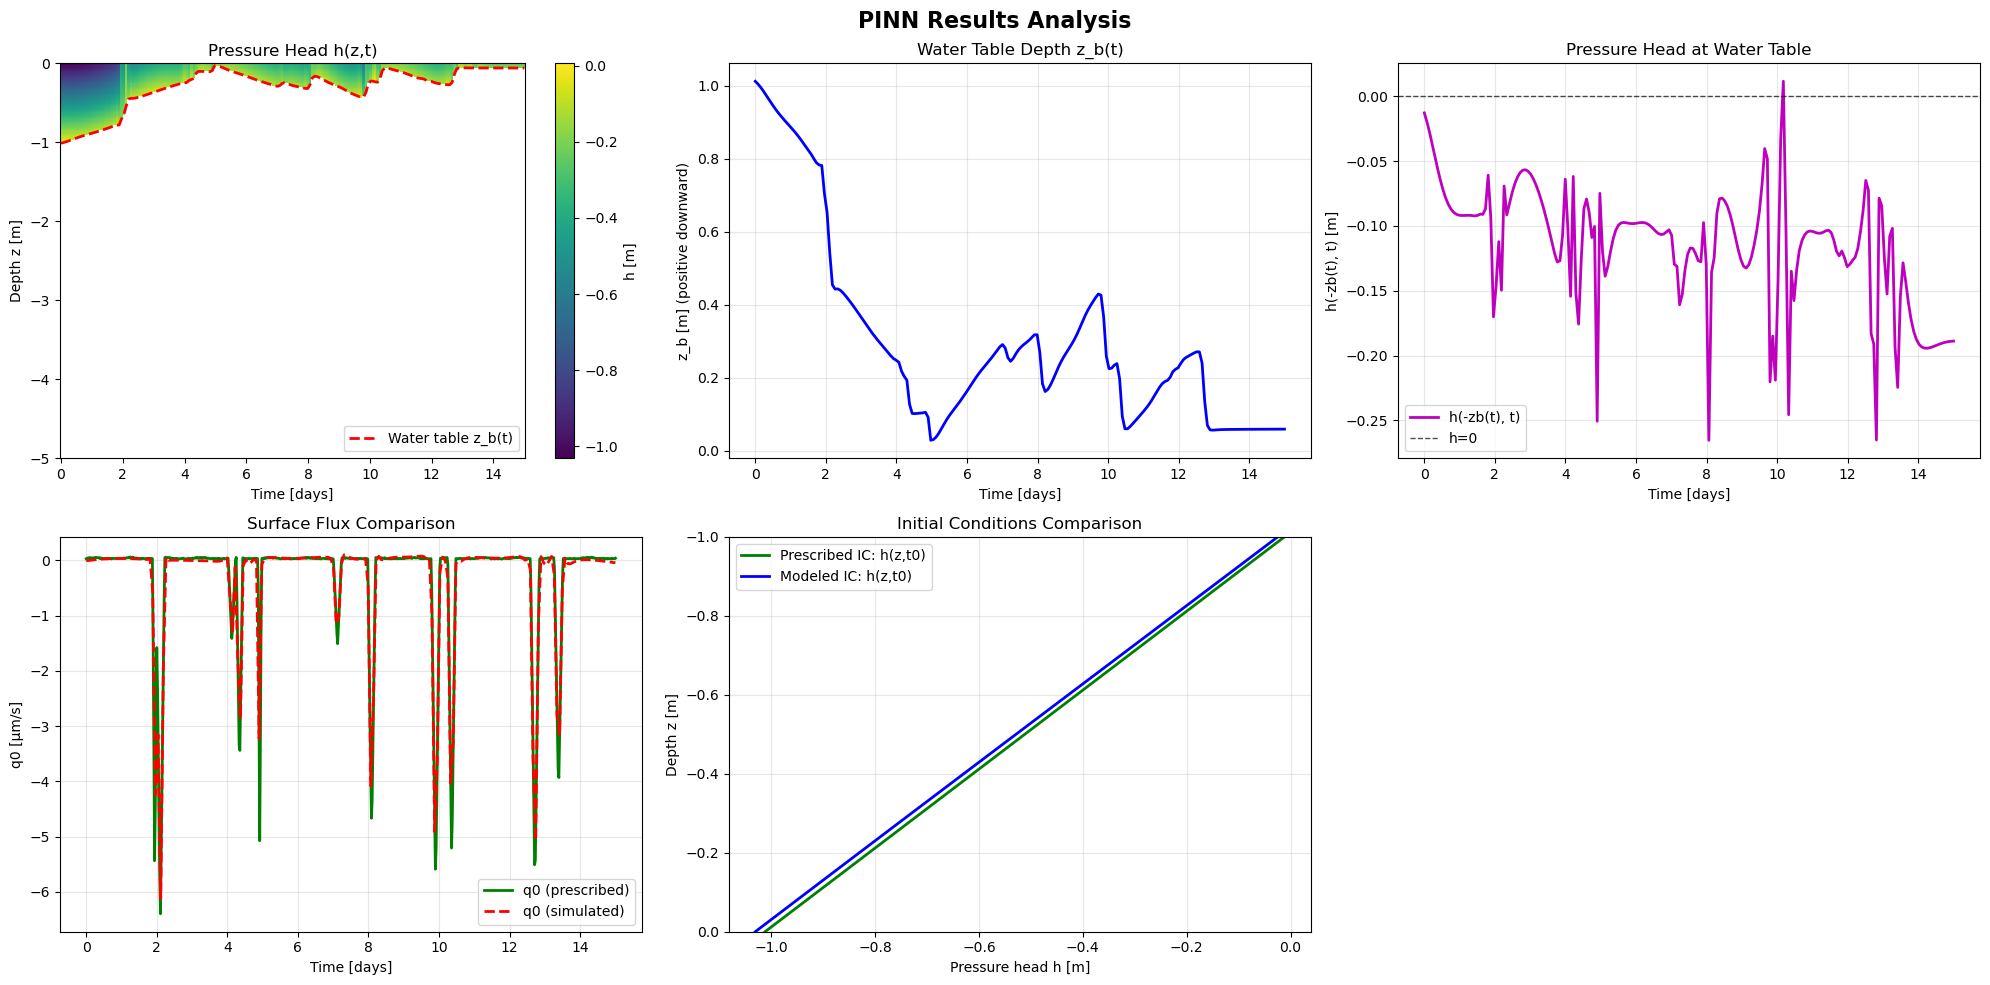


Summary Statistics:
Water table depth range: 0.029 to 1.012 m
Surface head range: -1.031 to -0.103 m
h(-zb(t), t) range: -0.265307 to 0.011582 m
Max |h(-zb(t), t)|: 0.265307 m (should be close to 0)
Max IC error: 0.018818 m


In [62]:
# Import visualization functions from external module
from src.visualization import plot_comprehensive_results
plot_comprehensive_results(model_pool, q_actual_flux, soil_params, device=device)

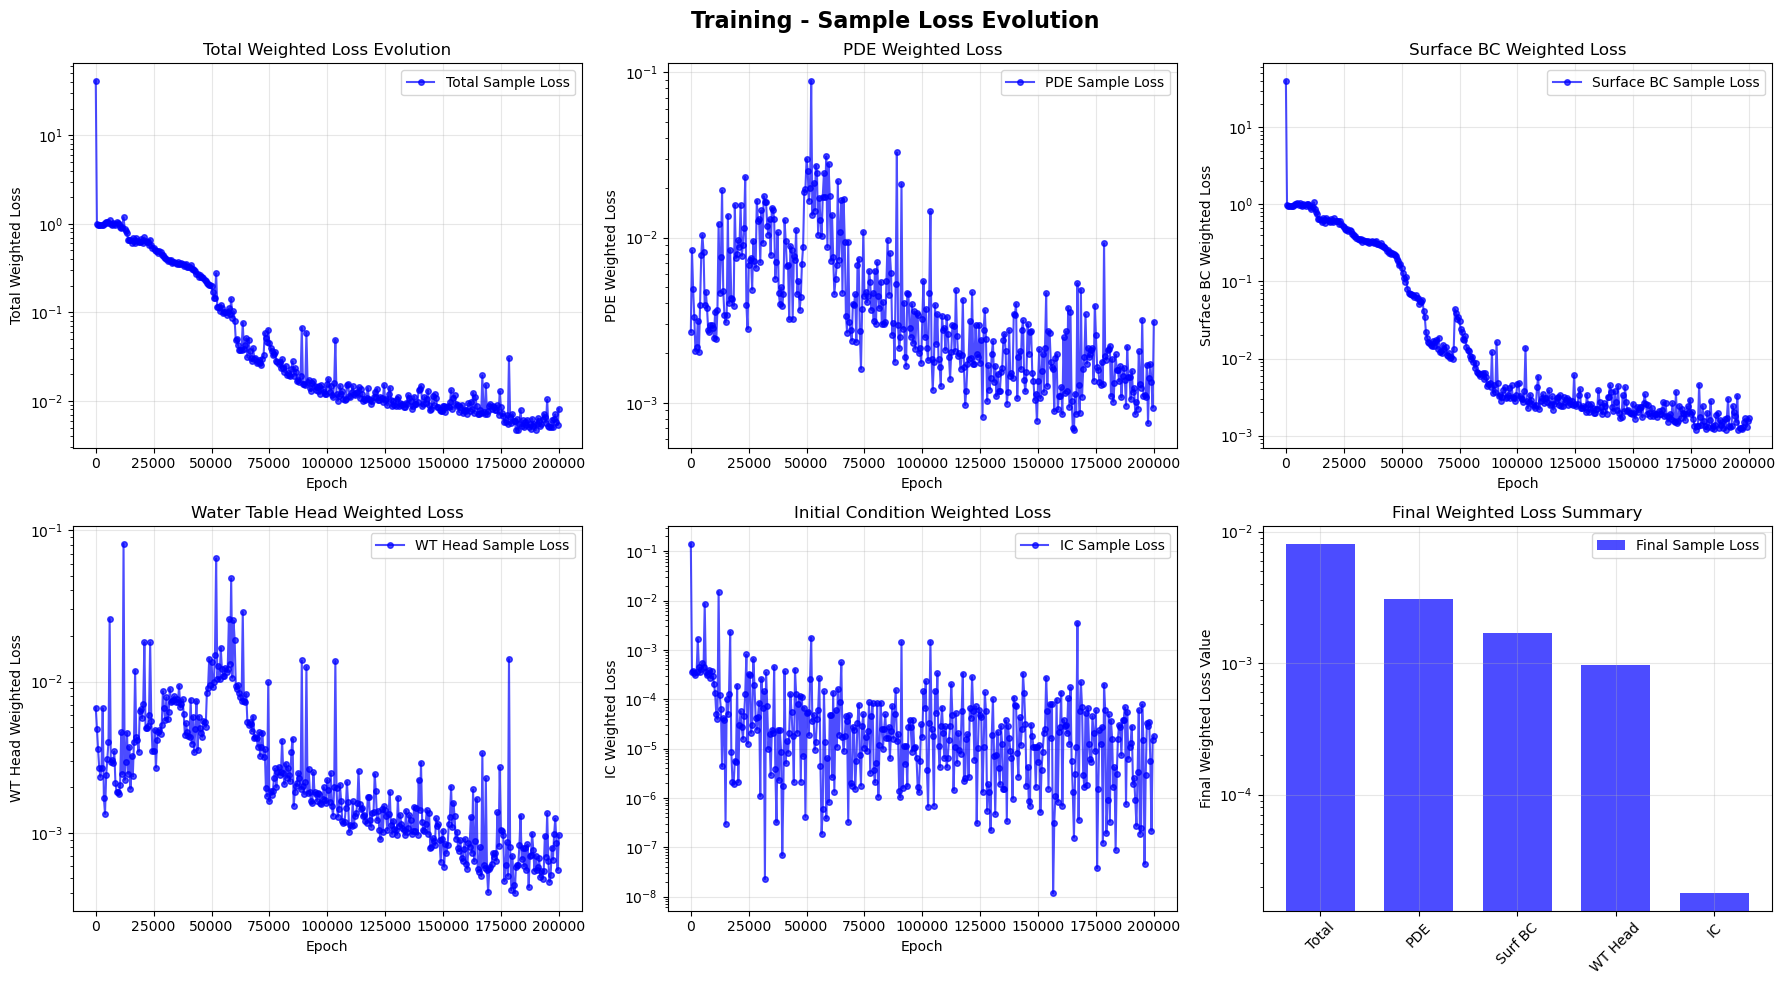

In [63]:
# Import and use the loss plotting function from external module
from src.visualization import plot_training_losses

# Plot the sample losses (computed over full dataset every 500 epochs)
# This gives a smoother, less noisy view of the loss evolution
plot_training_losses(losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs)